# Lab 5 - Time Series Analysis

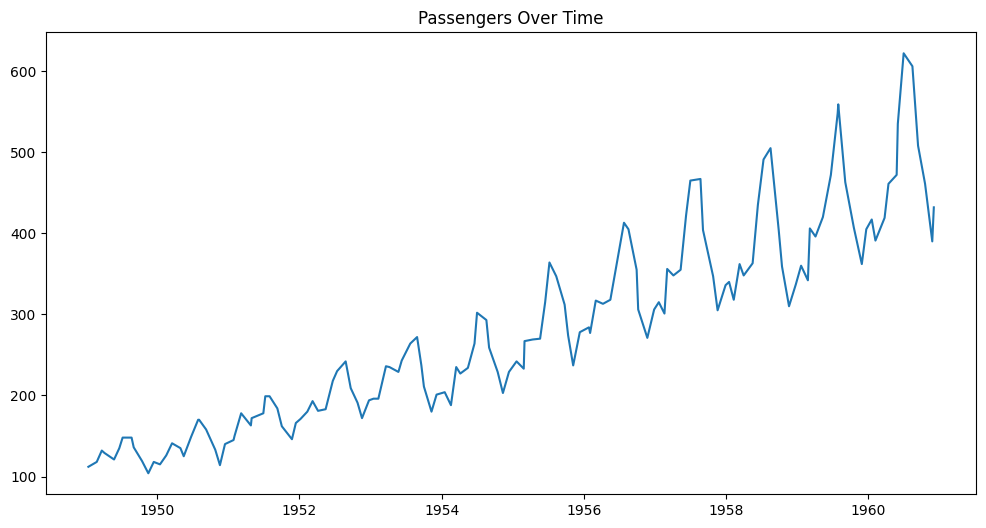

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\moham\OneDrive\Documents\ESAIP\ING4\visualisation\Data_Visualization_Course_2026\Interactive-Data-Visualization-with-Python\datasets\chap5_data\AirPassengersDates.csv")
df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["#Passengers"])
plt.title("Passengers Over Time")
plt.show()


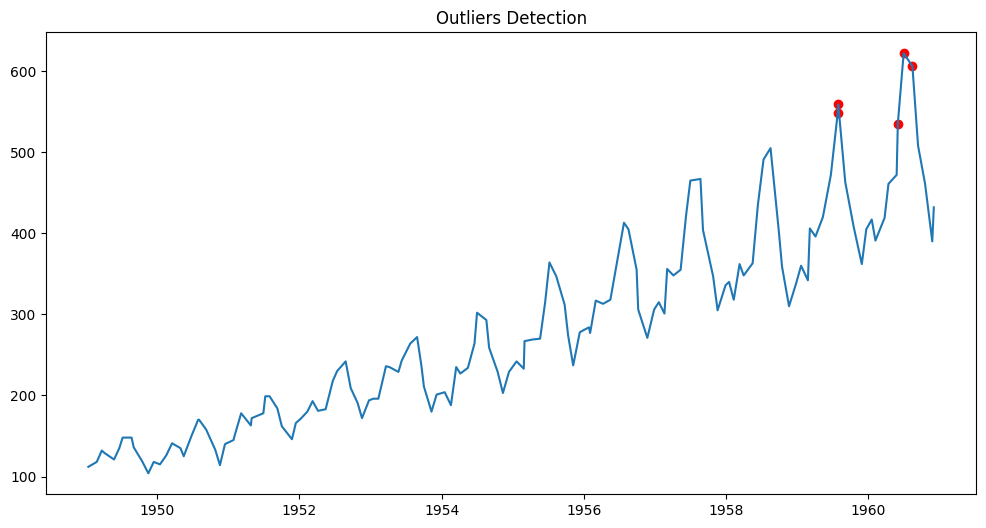

In [5]:

mean = df["#Passengers"].mean()
std = df["#Passengers"].std()

df["Z_score"] = (df["#Passengers"] - mean) / std
outliers = df[np.abs(df["Z_score"]) > 2]

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["#Passengers"])
plt.scatter(outliers["Date"], outliers["#Passengers"], color='red')
plt.title("Outliers Detection")
plt.show()


In [6]:

yearly = df.set_index("Date").resample("Y").mean()
daily = df.set_index("Date").resample("D").interpolate()

print(yearly.head())
print(daily.head())


            #Passengers   Z_score
Date                             
1949-12-31   126.666667 -1.280626
1950-12-31   139.666667 -1.172262
1951-12-31   170.166667 -0.918024
1952-12-31   197.000000 -0.694350
1953-12-31   225.000000 -0.460951
            #Passengers   Z_score
Date                             
1949-01-12   112.000000 -1.402882
1949-01-13   112.139535 -1.401719
1949-01-14   112.279070 -1.400556
1949-01-15   112.418605 -1.399393
1949-01-16   112.558140 -1.398230


C:\Users\moham\AppData\Local\Temp\ipykernel_17824\1077480410.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.set_index("Date").resample("Y").mean()


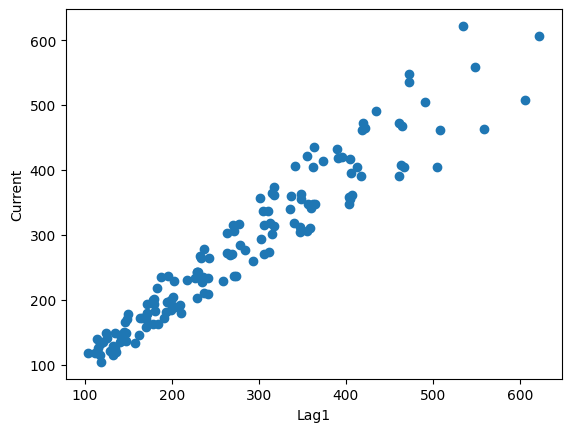

In [7]:

df["Lag1"] = df["#Passengers"].shift(1)

plt.scatter(df["Lag1"], df["#Passengers"])
plt.xlabel("Lag1")
plt.ylabel("Current")
plt.show()


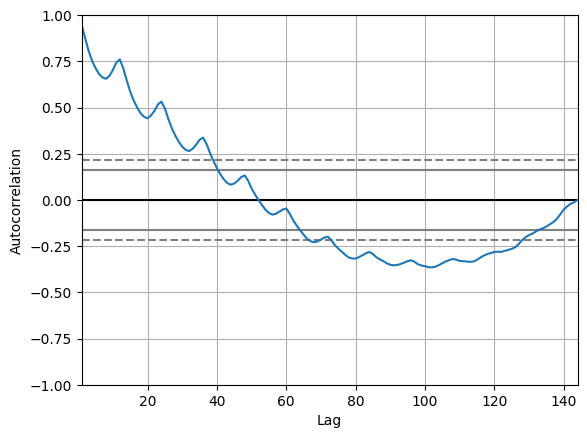

In [8]:

from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df["#Passengers"])
plt.show()
